# Lesson 08 — Temporal & Process Graphs

## Learning Objectives

1. **Understand temporal graphs**: How relationships change over time
2. **Build directly-follows graphs**: From event sequences
3. **Discover process bottlenecks**: Where time gets stuck
4. **Detect anomalies**: Rework loops, escalation spikes, stuck cases
5. **Analyze before/after**: Impact of process improvements

## Key Insight

**Process is a graph that changes over time.** Each step (activity) can follow many others. When you trace all cases through their steps, you discover the real process—and its problems. Bottlenecks appear as slow transitions. Rework loops appear as repeated activities. Process mining helps you **see** the process so you can **improve** it.

## Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Path resolution with robust fallback
data_dir = None

# Try multiple paths in order
fallback_paths = []

try:
    from src.config import Config
    fallback_paths.append(Config.PROJECT_ROOT / 'data' / 'seed' / 'support_escalation')
except:
    pass

# Add notebook-relative paths
fallback_paths.append(Path.cwd() / 'data' / 'seed' / 'support_escalation')  # Run from notebooks dir
fallback_paths.append(Path.cwd().parent / 'data' / 'seed' / 'support_escalation')  # Run from repo root

# Use first existing path
for path in fallback_paths:
    if path.exists():
        data_dir = path
        break

assert data_dir is not None, f"Data directory not found. Tried: {fallback_paths}"
print(f"Data directory: {data_dir}")

Data directory: /home/marek/Apps/graph-analysis-course/data/seed/support_escalation


In [3]:
# Load data
tickets_df = pd.read_csv(data_dir / 'tickets.csv')
events_df = pd.read_csv(data_dir / 'ticket_events.csv')

print(f"Tickets: {len(tickets_df)} records")
print(f"Events: {len(events_df)} records")
print(f"\nDate range: {events_df['timestamp'].min()} to {events_df['timestamp'].max()}")

Tickets: 50 records
Events: 291 records

Date range: 2024-01-02T04:42:35 to 2024-11-28T08:04:33


## 1. Understanding the Event Log

In [4]:
# Display sample events
print("Sample events (first 10):")
print(events_df.head(10).to_string())

Sample events (first 10):
     event_id   case_id           activity        actor        team            timestamp  duration_minutes  resolution_value
0  EVT_000000  TKT_0001     Ticket Created       SYSTEM     support  2024-01-02T04:42:35                 1               500
1  EVT_000001  TKT_0001  Assigned to Agent  AGENT_L1_03     support  2024-01-02T04:43:35                12               500
2  EVT_000002  TKT_0001      In Resolution  AGENT_L1_03     support  2024-01-02T04:55:35               218               500
3  EVT_000003  TKT_0001           Resolved  AGENT_L1_03     support  2024-01-02T08:33:35                25               500
4  EVT_000004  TKT_0001             Closed       SYSTEM     support  2024-01-02T08:58:35                 2               500
5  EVT_000005  TKT_0002     Ticket Created       SYSTEM     support  2024-01-15T14:45:52                 1                50
6  EVT_000006  TKT_0002  Assigned to Agent  AGENT_L1_01     support  2024-01-15T14:46:52           

In [5]:
# Event log statistics
print(f"\n=== Event Log Statistics ===")
print(f"Total events: {len(events_df)}")
print(f"Unique cases (tickets): {events_df['case_id'].nunique()}")
print(f"Unique activities: {events_df['activity'].nunique()}")
print(f"\nActivity distribution:")
print(events_df['activity'].value_counts())


=== Event Log Statistics ===
Total events: 291
Unique cases (tickets): 50
Unique activities: 7

Activity distribution:
activity
Assigned to Agent      59
Resolved               57
Ticket Created         50
In Resolution          50
Closed                 50
Escalated              18
Waiting on Customer     7
Name: count, dtype: int64


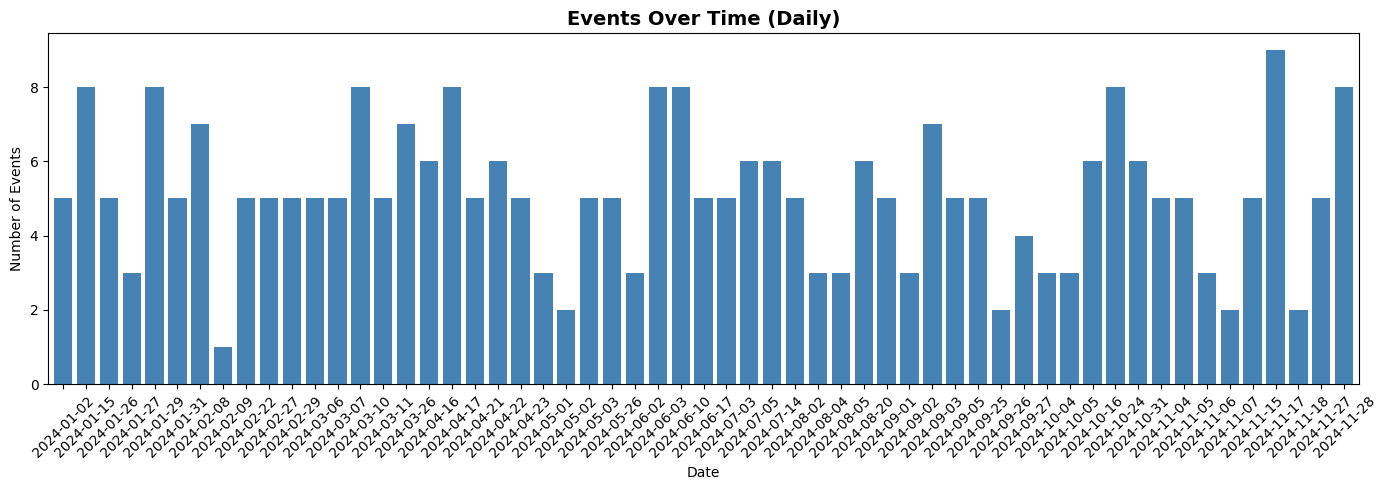

Event spike detected: Max 9 events on 2024-11-17


In [6]:
# Timeline visualization: Events over time
events_df['date'] = pd.to_datetime(events_df['timestamp']).dt.date
daily_events = events_df.groupby('date').size()

fig, ax = plt.subplots(figsize=(14, 5))
daily_events.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.set_title('Events Over Time (Daily)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Event spike detected: Max {daily_events.max()} events on {daily_events.idxmax()}")

## 2. Building the Directly-Follows Graph (DFG)

In [7]:
def build_directly_follows_graph(events_df, case_col='case_id', activity_col='activity', timestamp_col='timestamp'):
    """
    Build directly-follows graph from event log.
    
    For each case, sequences activities by timestamp and creates edges.
    
    Returns:
        NetworkX DiGraph with edges weighted by frequency
    """
    # Convert timestamp to datetime
    events_df = events_df.copy()
    events_df[timestamp_col] = pd.to_datetime(events_df[timestamp_col])
    
    # Sort by case and timestamp
    events_df = events_df.sort_values([case_col, timestamp_col])
    
    # Build edges
    edges = []
    
    for case_id, group in events_df.groupby(case_col):
        activities = group[activity_col].values
        
        # Create edges between consecutive activities
        for i in range(len(activities) - 1):
            edges.append((activities[i], activities[i + 1]))
    
    # Count edge frequencies
    edge_counts = Counter(edges)
    
    # Create directed graph
    dfg = nx.DiGraph()
    
    # Add nodes (all activities)
    for activity in events_df[activity_col].unique():
        dfg.add_node(activity)
    
    # Add edges with weight = frequency
    for (from_act, to_act), count in edge_counts.items():
        dfg.add_edge(from_act, to_act, weight=count)
    
    return dfg, edge_counts

# Alias for consistency
build_dfg = build_directly_follows_graph

# Build DFG
dfg, edge_counts = build_directly_follows_graph(events_df)
print(f"\nDirectly-Follows Graph:")
print(f"  Nodes (activities): {dfg.number_of_nodes()}")
print(f"  Edges (transitions): {dfg.number_of_edges()}")


Directly-Follows Graph:
  Nodes (activities): 7
  Edges (transitions): 11


In [8]:
# Display DFG edges (transitions)
print("\nTop 20 Direct Transitions (most frequent):")
transitions_df = pd.DataFrame([
    {'from': from_act, 'to': to_act, 'count': count}
    for (from_act, to_act), count in sorted(edge_counts.items(), key=lambda x: x[1], reverse=True)[:20]
])
print(transitions_df.to_string(index=False))


Top 20 Direct Transitions (most frequent):
               from                  to  count
     Ticket Created   Assigned to Agent     50
      In Resolution            Resolved     50
           Resolved              Closed     50
  Assigned to Agent       In Resolution     36
  Assigned to Agent           Escalated     16
          Escalated   Assigned to Agent      9
           Resolved            Resolved      7
  Assigned to Agent Waiting on Customer      7
Waiting on Customer       In Resolution      7
          Escalated       In Resolution      7
             Closed           Escalated      2


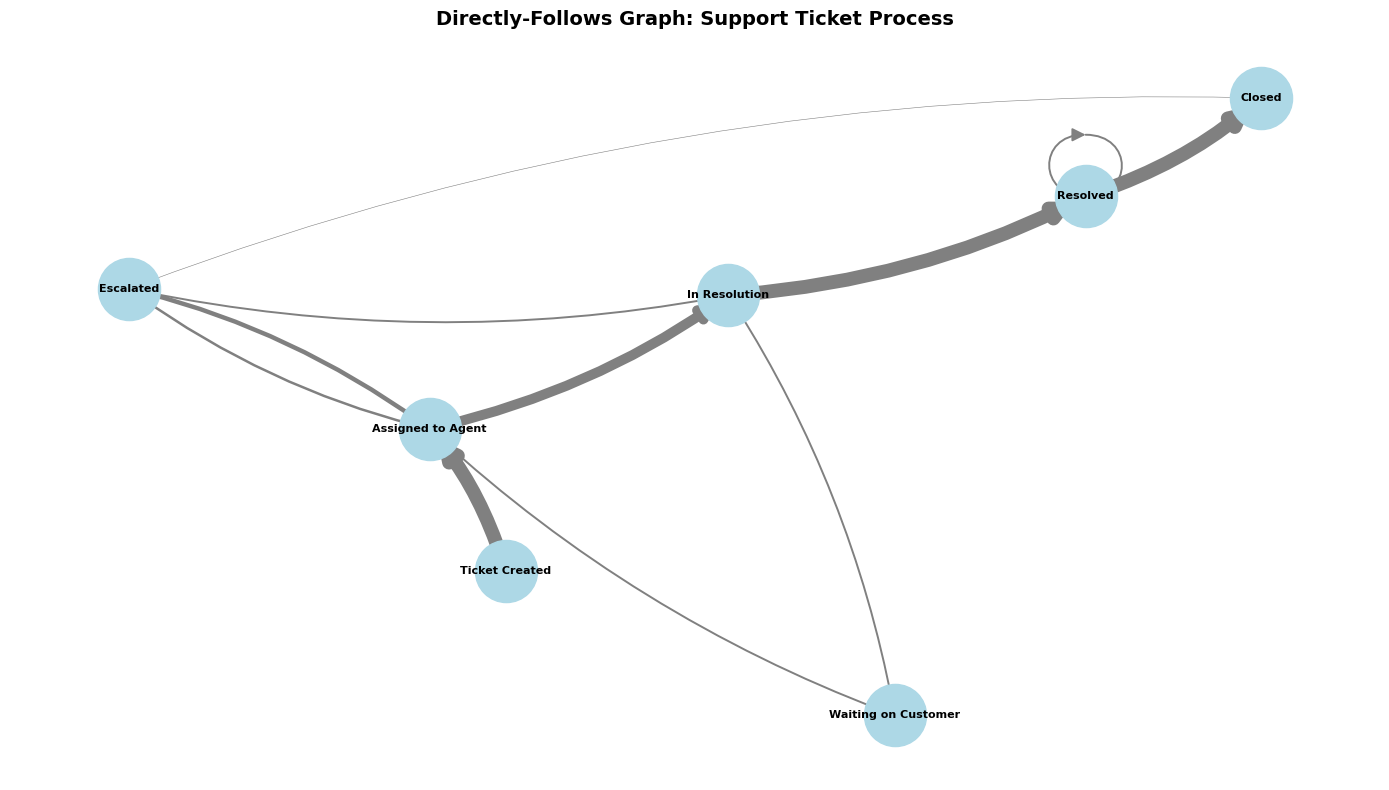

In [9]:
# Visualize DFG
pos = nx.spring_layout(dfg, k=2, iterations=50, seed=42)

fig, ax = plt.subplots(figsize=(14, 8))

# Draw nodes
nx.draw_networkx_nodes(dfg, pos, node_color='lightblue', node_size=2000, ax=ax)

# Draw edges with width = frequency
edge_widths = [dfg[u][v]['weight'] / 5 for u, v in dfg.edges()]
nx.draw_networkx_edges(dfg, pos, width=edge_widths, edge_color='gray', 
                        arrowsize=20, arrowstyle='-|>', ax=ax, connectionstyle='arc3,rad=0.1')

# Draw labels
nx.draw_networkx_labels(dfg, pos, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Directly-Follows Graph: Support Ticket Process', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Process Variants

In [10]:
def find_process_variants(events_df, case_col='case_id', activity_col='activity', timestamp_col='timestamp'):
    """
    Extract all unique process variants (activity sequences) from event log.
    
    Returns:
        DataFrame with columns: variant, count, avg_duration, case_examples
    """
    events_df = events_df.copy()
    events_df[timestamp_col] = pd.to_datetime(events_df[timestamp_col])
    events_df = events_df.sort_values([case_col, timestamp_col])
    
    variants = []
    
    for case_id, group in events_df.groupby(case_col):
        # Extract sequence of activities
        sequence = tuple(group[activity_col].values)
        
        # Compute case duration
        duration = (group[timestamp_col].max() - group[timestamp_col].min()).total_seconds() / 60  # minutes
        
        variants.append({
            'case_id': case_id,
            'variant': ' → '.join(sequence),
            'duration_minutes': duration,
            'num_activities': len(sequence)
        })
    
    variants_df = pd.DataFrame(variants)
    
    # Aggregate by variant
    variant_summary = variants_df.groupby('variant').agg({
        'case_id': 'count',
        'duration_minutes': ['mean', 'median', 'std'],
        'num_activities': 'first'
    }).round(1)
    
    variant_summary.columns = ['frequency', 'avg_duration', 'median_duration', 'std_duration', 'num_activities']
    variant_summary = variant_summary.sort_values('frequency', ascending=False)
    
    return variant_summary

# Find variants
variants = find_process_variants(events_df)
print(f"\nProcess Variants (top 10):")
print(variants.head(10))


Process Variants (top 10):
                                                    frequency  avg_duration  \
variant                                                                       
Ticket Created → Assigned to Agent → In Resolut...         28         223.2   
Ticket Created → Assigned to Agent → Escalated ...          7         326.1   
Ticket Created → Assigned to Agent → Escalated ...          6         194.3   
Ticket Created → Assigned to Agent → Waiting on...          5        1072.0   
Ticket Created → Assigned to Agent → Escalated ...          2         736.0   
Ticket Created → Assigned to Agent → Escalated ...          1         262.0   
Ticket Created → Assigned to Agent → In Resolut...          1         387.0   

                                                    median_duration  \
variant                                                               
Ticket Created → Assigned to Agent → In Resolut...            221.0   
Ticket Created → Assigned to Agent → Escalated 

In [11]:
# Variant statistics
print(f"\n=== Variant Statistics ===")
print(f"Total unique variants: {len(variants)}")
print(f"Most common variant frequency: {variants['frequency'].iloc[0]:.0f} cases ({variants['frequency'].iloc[0]/events_df['case_id'].nunique()*100:.1f}%)")
print(f"Average variant duration: {variants['avg_duration'].mean():.1f} minutes")
print(f"Median variant duration: {variants['median_duration'].median():.1f} minutes")


=== Variant Statistics ===
Total unique variants: 7
Most common variant frequency: 28 cases (56.0%)
Average variant duration: 457.2 minutes
Median variant duration: 340.0 minutes


## 4. Transition Time Analysis

In [12]:
def compute_transition_times(events_df, case_col='case_id', activity_col='activity', timestamp_col='timestamp'):
    """
    Compute transition time statistics for each edge in the DFG.
    
    Returns:
        DataFrame with columns: from_activity, to_activity, mean_time, median_time, p90_time, count
    """
    events_df = events_df.copy()
    events_df[timestamp_col] = pd.to_datetime(events_df[timestamp_col])
    events_df = events_df.sort_values([case_col, timestamp_col])
    
    transition_times = []
    
    for case_id, group in events_df.groupby(case_col):
        timestamps = group[timestamp_col].values
        activities = group[activity_col].values
        
        # Compute time between consecutive activities
        for i in range(len(activities) - 1):
            from_act = activities[i]
            to_act = activities[i + 1]
            time_diff = (pd.Timestamp(timestamps[i + 1]) - pd.Timestamp(timestamps[i])).total_seconds() / 60  # minutes
            
            transition_times.append({
                'from_activity': from_act,
                'to_activity': to_act,
                'duration_minutes': time_diff
            })
    
    trans_df = pd.DataFrame(transition_times)
    
    # Aggregate by transition
    transition_stats = trans_df.groupby(['from_activity', 'to_activity']).agg({
        'duration_minutes': ['count', 'mean', 'median', lambda x: x.quantile(0.9), 'min', 'max']
    }).round(1)
    
    transition_stats.columns = ['count', 'mean', 'median', 'p90', 'min', 'max']
    transition_stats = transition_stats.sort_values('count', ascending=False)
    
    return transition_stats

# Compute transition times
trans_stats = compute_transition_times(events_df)
print(f"\nTransition Time Statistics (top 15):")
print(trans_stats.head(15))


Transition Time Statistics (top 15):
                                         count   mean  median     p90    min  \
from_activity       to_activity                                                
In Resolution       Resolved                50  167.9   167.5   262.1   38.0   
Resolved            Closed                  50   33.4    37.0    53.2    5.0   
Ticket Created      Assigned to Agent       50    1.0     1.0     1.0    1.0   
Assigned to Agent   In Resolution           36   15.6    14.0    27.0    5.0   
                    Escalated               16   16.9    18.5    26.0    5.0   
Escalated           Assigned to Agent        9    7.1     8.0     9.0    4.0   
Assigned to Agent   Waiting on Customer      7   14.1    13.0    25.0    6.0   
Escalated           In Resolution            7    5.4     4.0     8.8    2.0   
Resolved            Resolved                 7   50.6    51.0    58.2   41.0   
Waiting on Customer In Resolution            7  792.7   759.0  1187.6  214.0   
Cl

In [13]:
# Identify bottlenecks (slowest transitions)
bottlenecks = trans_stats.nlargest(5, 'mean')
print(f"\nBottlenecks (Slowest Transitions by Average Time):")
print(bottlenecks)


Bottlenecks (Slowest Transitions by Average Time):
                                   count   mean  median     p90    min     max
from_activity       to_activity                                               
Waiting on Customer In Resolution      7  792.7   759.0  1187.6  214.0  1196.0
In Resolution       Resolved          50  167.9   167.5   262.1   38.0   293.0
Closed              Escalated          2   65.5    65.5    68.3   62.0    69.0
Resolved            Resolved           7   50.6    51.0    58.2   41.0    60.0
                    Closed            50   33.4    37.0    53.2    5.0    59.0


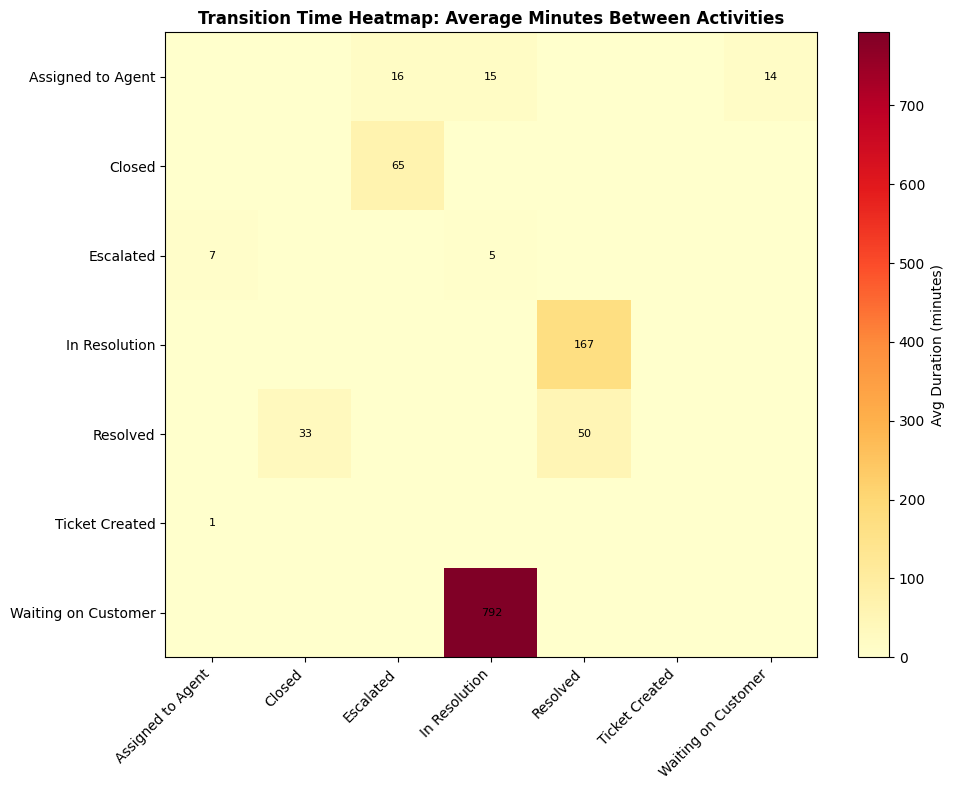

In [14]:
# Heatmap of transition times using matplotlib
# Create matrix for transitions
activities = sorted(events_df['activity'].unique())
transition_matrix = pd.DataFrame(0.0, index=activities, columns=activities)

for (from_act, to_act), row in trans_stats.iterrows():
    if from_act in activities and to_act in activities:
        transition_matrix.loc[from_act, to_act] = row['mean']

# Plot heatmap with matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(transition_matrix.values, cmap='YlOrRd', aspect='auto')

# Add text annotations
for i in range(len(activities)):
    for j in range(len(activities)):
        value = transition_matrix.values[i, j]
        if value > 0:
            ax.text(j, i, f'{int(value)}', ha='center', va='center', color='black', fontsize=8)

# Set ticks and labels
ax.set_xticks(range(len(activities)))
ax.set_yticks(range(len(activities)))
ax.set_xticklabels(activities, rotation=45, ha='right')
ax.set_yticklabels(activities, rotation=0)

ax.set_title('Transition Time Heatmap: Average Minutes Between Activities', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Avg Duration (minutes)')

plt.tight_layout()
plt.show()

## 5. Anomaly Detection

In [15]:
def detect_rework_loops(events_df, case_col='case_id', activity_col='activity'):
    """
    Detect cases with repeated activities (rework loops).
    
    Returns:
        DataFrame with cases that have rework patterns
    """
    rework_cases = []
    
    for case_id, group in events_df.groupby(case_col):
        activities = group[activity_col].values
        activity_counts = Counter(activities)
        
        # Find activities that occur more than once
        repeated_activities = [act for act, count in activity_counts.items() if count > 1]
        
        if repeated_activities:
            rework_cases.append({
                'case_id': case_id,
                'repeated_activities': ', '.join(repeated_activities),
                'num_events': len(activities),
                'rework_count': sum(activity_counts.values()) - len(activities)
            })
    
    return pd.DataFrame(rework_cases)

# Detect rework
rework_df = detect_rework_loops(events_df)
print(f"\n=== Rework Loop Detection ===")
print(f"Cases with rework: {len(rework_df)} out of {events_df['case_id'].nunique()} ({len(rework_df)/events_df['case_id'].nunique()*100:.1f}%)")

if len(rework_df) > 0:
    print(f"\nRework Cases (first 10):")
    print(rework_df.head(10).to_string(index=False))


=== Rework Loop Detection ===
Cases with rework: 10 out of 50 (20.0%)

Rework Cases (first 10):
 case_id         repeated_activities  num_events  rework_count
TKT_0002 Assigned to Agent, Resolved           8             0
TKT_0003           Assigned to Agent           8             0
TKT_0004 Assigned to Agent, Resolved           8             0
TKT_0006 Assigned to Agent, Resolved           8             0
TKT_0012 Assigned to Agent, Resolved           8             0
TKT_0014                   Escalated           7             0
TKT_0016 Assigned to Agent, Resolved           8             0
TKT_0025 Assigned to Agent, Resolved           8             0
TKT_0041           Assigned to Agent           8             0
TKT_0050 Assigned to Agent, Resolved           8             0


In [16]:
def detect_escalation_spike(events_df, timestamp_col='timestamp', activity_col='activity'):
    """
    Detect escalation spikes over time.
    
    Returns:
        DataFrame with daily escalation statistics
    """
    events_df = events_df.copy()
    events_df['date'] = pd.to_datetime(events_df[timestamp_col]).dt.date
    
    daily_stats = []
    
    for date, group in events_df.groupby('date'):
        total_activities = len(group)
        escalations = len(group[group[activity_col] == 'Escalated'])
        escalation_rate = escalations / total_activities if total_activities > 0 else 0
        
        daily_stats.append({
            'date': date,
            'total_activities': total_activities,
            'escalations': escalations,
            'escalation_rate': escalation_rate
        })
    
    daily_df = pd.DataFrame(daily_stats)
    
    # Identify spikes (> 1.5x average rate)
    avg_rate = daily_df['escalation_rate'].mean()
    daily_df['is_spike'] = daily_df['escalation_rate'] > avg_rate * 1.5
    
    return daily_df

# Detect escalation spike
escalation_daily = detect_escalation_spike(events_df)
print(f"\n=== Escalation Spike Detection ===")
print(f"Average escalation rate: {escalation_daily['escalation_rate'].mean():.1%}")
print(f"Days with spike: {escalation_daily['is_spike'].sum()}")

if escalation_daily['is_spike'].any():
    print(f"\nSpike days:")
    print(escalation_daily[escalation_daily['is_spike']].to_string(index=False))


=== Escalation Spike Detection ===
Average escalation rate: 4.6%
Days with spike: 17

Spike days:
      date  total_activities  escalations  escalation_rate  is_spike
2024-01-15                 8            1         0.125000      True
2024-01-26                 5            1         0.200000      True
2024-01-29                 8            1         0.125000      True
2024-02-08                 7            1         0.142857      True
2024-03-10                 8            1         0.125000      True
2024-03-26                 7            2         0.285714      True
2024-04-16                 6            1         0.166667      True
2024-04-17                 8            1         0.125000      True
2024-06-10                 8            1         0.125000      True
2024-07-05                 6            1         0.166667      True
2024-07-14                 6            1         0.166667      True
2024-08-20                 6            1         0.166667      True
2024

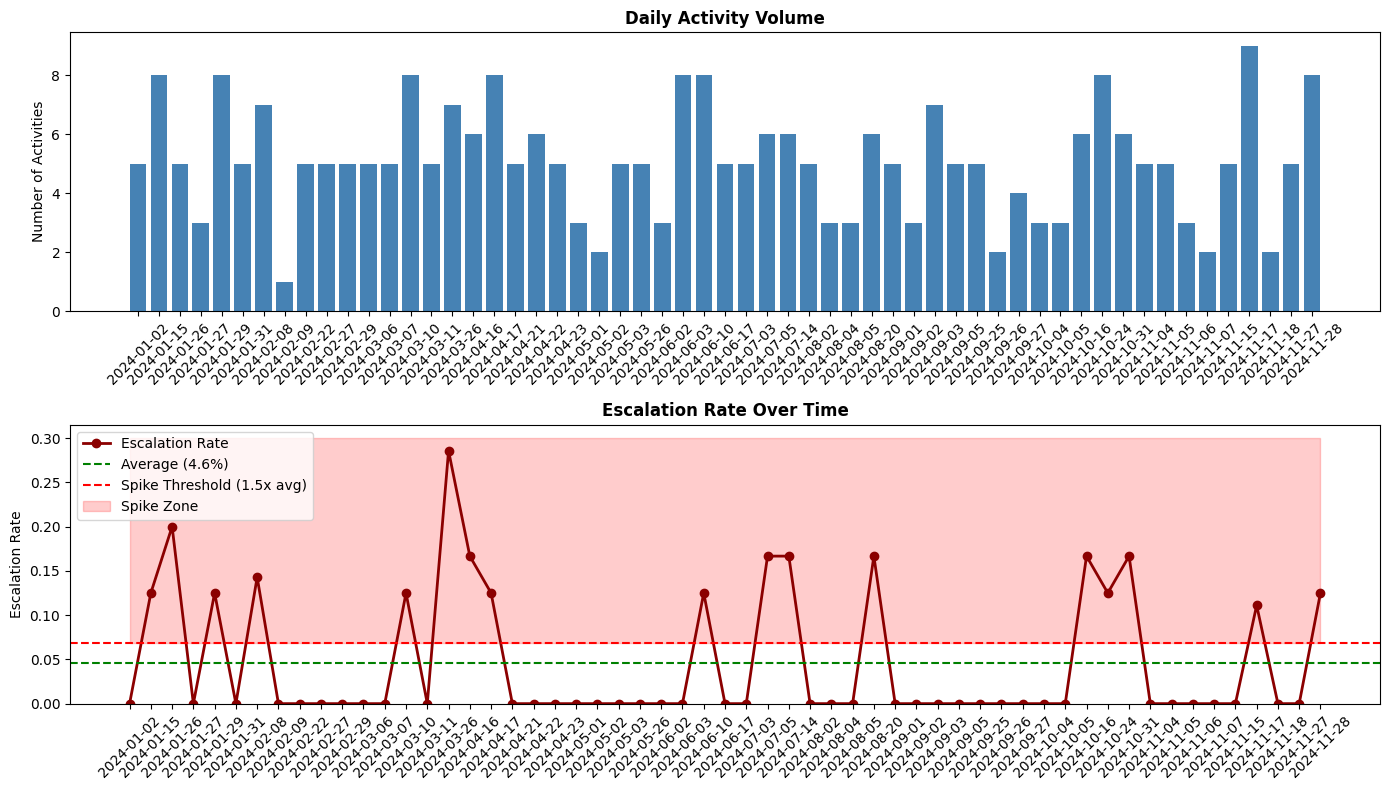

In [17]:
# Visualize escalation spike
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Total activities
ax1.bar(escalation_daily['date'].astype(str), escalation_daily['total_activities'], color='steelblue')
ax1.set_title('Daily Activity Volume', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Activities')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Escalation rate
avg_rate = escalation_daily['escalation_rate'].mean()
ax2.plot(escalation_daily['date'].astype(str), escalation_daily['escalation_rate'], 
         marker='o', color='darkred', linewidth=2, label='Escalation Rate')
ax2.axhline(y=avg_rate, color='green', linestyle='--', label=f'Average ({avg_rate:.1%})')
ax2.axhline(y=avg_rate * 1.5, color='red', linestyle='--', label='Spike Threshold (1.5x avg)')
ax2.fill_between(range(len(escalation_daily)), avg_rate * 1.5, ax2.get_ylim()[1], 
                   alpha=0.2, color='red', label='Spike Zone')
ax2.set_title('Escalation Rate Over Time', fontsize=12, fontweight='bold')
ax2.set_ylabel('Escalation Rate')
ax2.set_ylim(bottom=0)
ax2.legend(loc='upper left')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [18]:
def detect_stuck_cases(events_df, case_col='case_id', timestamp_col='timestamp', duration_threshold=None):
    """
    Detect cases that take unusually long or cycle through many agents.
    
    Returns:
        DataFrame with stuck case information
    """
    events_df = events_df.copy()
    events_df[timestamp_col] = pd.to_datetime(events_df[timestamp_col])
    
    stuck_cases = []
    
    all_durations = []
    
    # First pass: compute all case durations
    for case_id, group in events_df.groupby(case_col):
        duration = (group[timestamp_col].max() - group[timestamp_col].min()).total_seconds() / 60
        all_durations.append(duration)
    
    if duration_threshold is None:
        median_duration = np.median(all_durations)
        duration_threshold = median_duration * 2
    
    # Second pass: identify stuck cases
    for case_id, group in events_df.groupby(case_col):
        duration = (group[timestamp_col].max() - group[timestamp_col].min()).total_seconds() / 60
        num_events = len(group)
        num_actors = group['actor'].nunique()
        
        is_stuck = duration > duration_threshold or num_actors > 3
        
        if is_stuck:
            stuck_cases.append({
                'case_id': case_id,
                'duration_minutes': round(duration, 1),
                'num_events': num_events,
                'num_actors': num_actors,
                'reason': 'Long duration' if duration > duration_threshold else 'Multiple handoffs'
            })
    
    return pd.DataFrame(stuck_cases).sort_values('duration_minutes', ascending=False)

# Detect stuck cases
stuck_cases = detect_stuck_cases(events_df)
print(f"\n=== Stuck Cases Detection ===")
print(f"Total stuck cases: {len(stuck_cases)} out of {events_df['case_id'].nunique()}")

if len(stuck_cases) > 0:
    print(f"\nStuck Cases (first 10):")
    print(stuck_cases.head(10).to_string(index=False))


=== Stuck Cases Detection ===
Total stuck cases: 8 out of 50

Stuck Cases (first 10):
 case_id  duration_minutes  num_events  num_actors            reason
TKT_0031            1424.0           6           2     Long duration
TKT_0023            1387.0           6           2     Long duration
TKT_0003            1054.0           8           3     Long duration
TKT_0039             937.0           6           2     Long duration
TKT_0018             836.0           6           2     Long duration
TKT_0038             776.0           6           2     Long duration
TKT_0016             344.0           8           4 Multiple handoffs
TKT_0014             262.0           7           4 Multiple handoffs


## 6. Before/After Scenarios

In [19]:
def compute_process_metrics(events_df, case_col='case_id', activity_col='activity', timestamp_col='timestamp'):
    """
    Compute key process metrics from event log.
    
    Returns:
        Dictionary with metrics: avg_duration, escalation_rate, rework_rate, median_duration, p90_duration
    """
    events_df = events_df.copy()
    events_df[timestamp_col] = pd.to_datetime(events_df[timestamp_col])
    
    case_metrics = []
    
    for case_id, group in events_df.groupby(case_col):
        duration = (group[timestamp_col].max() - group[timestamp_col].min()).total_seconds() / 60
        has_escalation = 'Escalated' in group[activity_col].values
        
        # Count rework (repeated activities)
        activity_counts = group[activity_col].value_counts()
        has_rework = (activity_counts > 1).any()
        
        case_metrics.append({
            'case_id': case_id,
            'duration': duration,
            'escalated': has_escalation,
            'reworked': has_rework
        })
    
    metrics_df = pd.DataFrame(case_metrics)
    
    return {
        'avg_duration': metrics_df['duration'].mean(),
        'median_duration': metrics_df['duration'].median(),
        'p90_duration': metrics_df['duration'].quantile(0.9),
        'escalation_rate': metrics_df['escalated'].mean(),
        'rework_rate': metrics_df['reworked'].mean()
    }

# Baseline metrics
baseline_metrics = compute_process_metrics(events_df)
print(f"\n=== BASELINE PROCESS METRICS ===")
for key, value in baseline_metrics.items():
    if 'rate' in key:
        print(f"{key:20s}: {value:.1%}")
    else:
        print(f"{key:20s}: {value:.1f} minutes")


=== BASELINE PROCESS METRICS ===
avg_duration        : 343.6 minutes
median_duration     : 259.0 minutes
p90_duration        : 782.0 minutes
escalation_rate     : 34.0%
rework_rate         : 20.0%


In [20]:
def simulate_scenario_reduce_rework(events_df, rework_reduction=0.95):
    """
    Scenario: Reduce rework by improving first-pass resolution.
    
    Simulates: 95% of reworked cases get resolved on second try instead of cycling.
    """
    events_df = events_df.copy()
    events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])
    
    # Find rework cases and shorten their duration
    for case_id in events_df['case_id'].unique():
        case_events = events_df[events_df['case_id'] == case_id]
        activity_counts = case_events['activity'].value_counts()
        
        if (activity_counts > 1).any() and np.random.random() < rework_reduction:
            # Remove duplicated events (keep only first occurrence of each activity)
            seen_activities = set()
            indices_to_keep = []
            
            for idx, row in case_events.iterrows():
                if row['activity'] not in seen_activities:
                    indices_to_keep.append(idx)
                    seen_activities.add(row['activity'])
            
            events_df.loc[case_events.index.difference(indices_to_keep), 'timestamp'] = pd.NaT
    
    # Remove rows with NaT timestamp
    events_df = events_df.dropna(subset=['timestamp'])
    
    return events_df

# Simulate scenario
scenario1_events = simulate_scenario_reduce_rework(events_df.copy())
scenario1_metrics = compute_process_metrics(scenario1_events)

print(f"\n=== SCENARIO 1: Reduce Rework ===")
print(f"avg_duration (baseline): {baseline_metrics['avg_duration']:.1f} → {scenario1_metrics['avg_duration']:.1f} ({(scenario1_metrics['avg_duration']/baseline_metrics['avg_duration']-1)*100:.1f}%)")
print(f"rework_rate (baseline):  {baseline_metrics['rework_rate']:.1%} → {scenario1_metrics['rework_rate']:.1%}")


=== SCENARIO 1: Reduce Rework ===
avg_duration (baseline): 343.6 → 342.2 (-0.4%)
rework_rate (baseline):  20.0% → 0.0%


In [21]:
def simulate_scenario_ai_intake(events_df, skip_escalation_rate=0.30):
    """
    Scenario: AI-powered intake checker reduces unnecessary escalations.
    
    Simulates: 30% of escalations are prevented by better routing upfront.
    """
    events_df = events_df.copy()
    events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])
    
    # Find escalation events and remove some
    escalation_indices = events_df[events_df['activity'] == 'Escalated'].index
    to_remove = np.random.choice(escalation_indices, 
                                 size=int(len(escalation_indices) * skip_escalation_rate),
                                 replace=False)
    
    events_df = events_df.drop(to_remove)
    
    return events_df

# Simulate scenario
scenario2_events = simulate_scenario_ai_intake(events_df.copy())
scenario2_metrics = compute_process_metrics(scenario2_events)

print(f"\n=== SCENARIO 2: AI Intake Checker ===")
print(f"avg_duration (baseline): {baseline_metrics['avg_duration']:.1f} → {scenario2_metrics['avg_duration']:.1f} ({(scenario2_metrics['avg_duration']/baseline_metrics['avg_duration']-1)*100:.1f}%)")
print(f"escalation_rate (baseline): {baseline_metrics['escalation_rate']:.1%} → {scenario2_metrics['escalation_rate']:.1%}")


=== SCENARIO 2: AI Intake Checker ===
avg_duration (baseline): 343.6 → 343.6 (0.0%)
escalation_rate (baseline): 34.0% → 24.0%


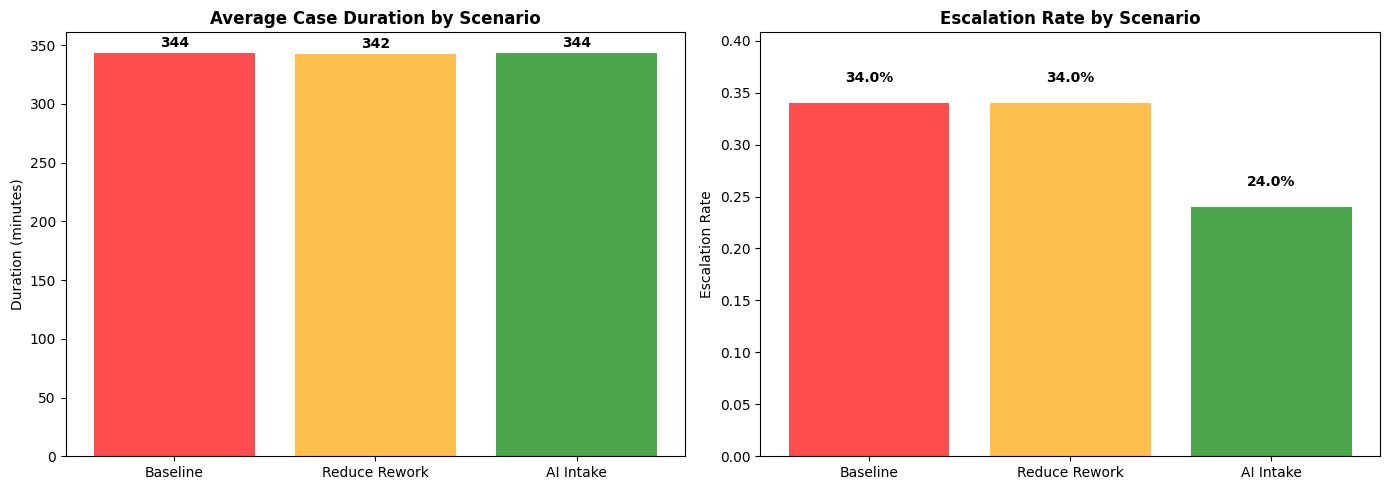

In [22]:
# Comparison chart
scenarios = ['Baseline', 'Reduce Rework', 'AI Intake']
avg_durations = [
    baseline_metrics['avg_duration'],
    scenario1_metrics['avg_duration'],
    scenario2_metrics['avg_duration']
]
escalation_rates = [
    baseline_metrics['escalation_rate'],
    scenario1_metrics['escalation_rate'],
    scenario2_metrics['escalation_rate']
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Average duration
colors = ['red', 'orange', 'green']
ax1.bar(scenarios, avg_durations, color=colors, alpha=0.7)
ax1.set_title('Average Case Duration by Scenario', fontsize=12, fontweight='bold')
ax1.set_ylabel('Duration (minutes)')
for i, v in enumerate(avg_durations):
    ax1.text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

# Escalation rate
ax2.bar(scenarios, escalation_rates, color=colors, alpha=0.7)
ax2.set_title('Escalation Rate by Scenario', fontsize=12, fontweight='bold')
ax2.set_ylabel('Escalation Rate')
ax2.set_ylim(0, max(escalation_rates) * 1.2)
for i, v in enumerate(escalation_rates):
    ax2.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Temporal Metrics & Evolution

In [23]:
# Case duration distribution
case_durations = []

events_df_sorted = events_df.copy()
events_df_sorted['timestamp'] = pd.to_datetime(events_df_sorted['timestamp'])

for case_id, group in events_df_sorted.groupby('case_id'):
    duration = (group['timestamp'].max() - group['timestamp'].min()).total_seconds() / 60
    case_durations.append(duration)

case_durations = np.array(case_durations)

print(f"\n=== Case Duration Statistics ===")
print(f"Mean: {case_durations.mean():.1f} minutes")
print(f"Median: {np.median(case_durations):.1f} minutes")
print(f"p25: {np.percentile(case_durations, 25):.1f} minutes")
print(f"p75: {np.percentile(case_durations, 75):.1f} minutes")
print(f"p90: {np.percentile(case_durations, 90):.1f} minutes")
print(f"p99: {np.percentile(case_durations, 99):.1f} minutes")


=== Case Duration Statistics ===
Mean: 343.6 minutes
Median: 259.0 minutes
p25: 181.8 minutes
p75: 343.0 minutes
p90: 782.0 minutes
p99: 1405.9 minutes


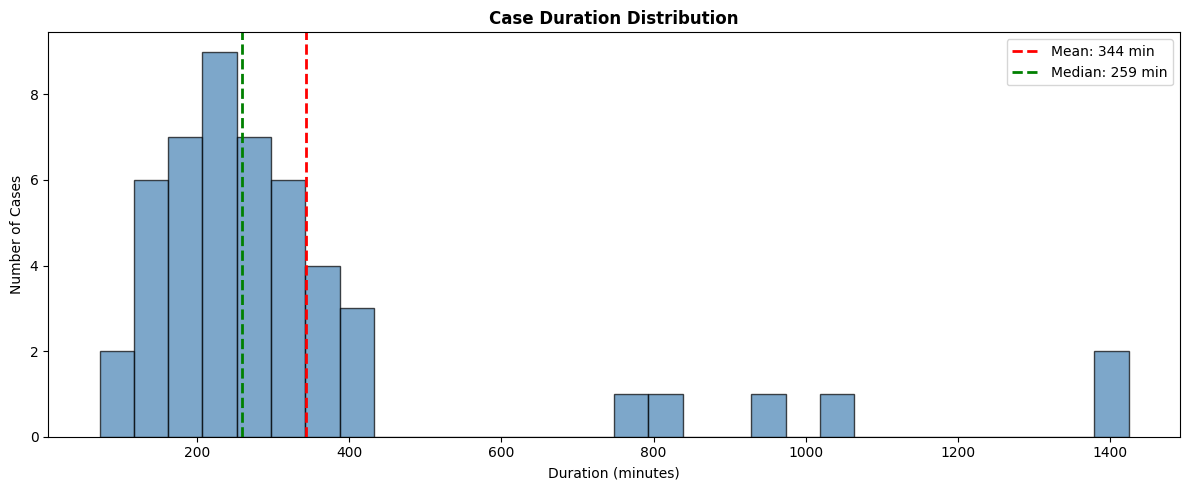

In [24]:
# Duration histogram
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(case_durations, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(case_durations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {case_durations.mean():.0f} min')
ax.axvline(np.median(case_durations), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(case_durations):.0f} min')

ax.set_title('Case Duration Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Cases')
ax.legend()

plt.tight_layout()
plt.show()

In [25]:
# Weekly evolution of process metrics
events_df_sorted['week'] = pd.to_datetime(events_df_sorted['timestamp']).dt.isocalendar().week

weekly_metrics = []

for week in sorted(events_df_sorted['week'].unique()):
    week_events = events_df_sorted[events_df_sorted['week'] == week]
    
    # Compute metrics for this week
    cases_in_week = week_events['case_id'].unique()
    durations = []
    escalations = 0
    total = len(week_events)
    
    for case_id in cases_in_week:
        case_events = week_events[week_events['case_id'] == case_id]
        duration = (case_events['timestamp'].max() - case_events['timestamp'].min()).total_seconds() / 60
        durations.append(duration)
        
        if 'Escalated' in case_events['activity'].values:
            escalations += 1
    
    escalation_rate = escalations / len(cases_in_week) if cases_in_week.size > 0 else 0
    
    weekly_metrics.append({
        'week': week,
        'avg_duration': np.mean(durations) if durations else 0,
        'escalation_rate': escalation_rate,
        'cases': len(cases_in_week)
    })

weekly_df = pd.DataFrame(weekly_metrics)

print(f"\nWeekly Metrics:")
print(weekly_df)


Weekly Metrics:
    week  avg_duration  escalation_rate  cases
0      1    256.000000         0.000000      1
1      3    267.000000         1.000000      1
2      4   1054.000000         1.000000      1
3      5    173.000000         0.500000      2
4      6    432.000000         1.000000      1
5      8    140.000000         0.000000      1
6      9    287.500000         0.000000      2
7     10    273.666667         0.333333      3
8     11    142.000000         0.000000      1
9     13    262.000000         1.000000      1
10    16    303.666667         0.666667      3
11    17    580.500000         0.000000      2
12    18    294.500000         0.000000      2
13    21    220.000000         0.000000      1
14    22      8.000000         0.000000      1
15    23    250.500000         0.000000      2
16    24    340.000000         1.000000      1
17    25    231.000000         0.000000      1
18    27    226.000000         0.500000      2
19    28    177.000000         1.000000    

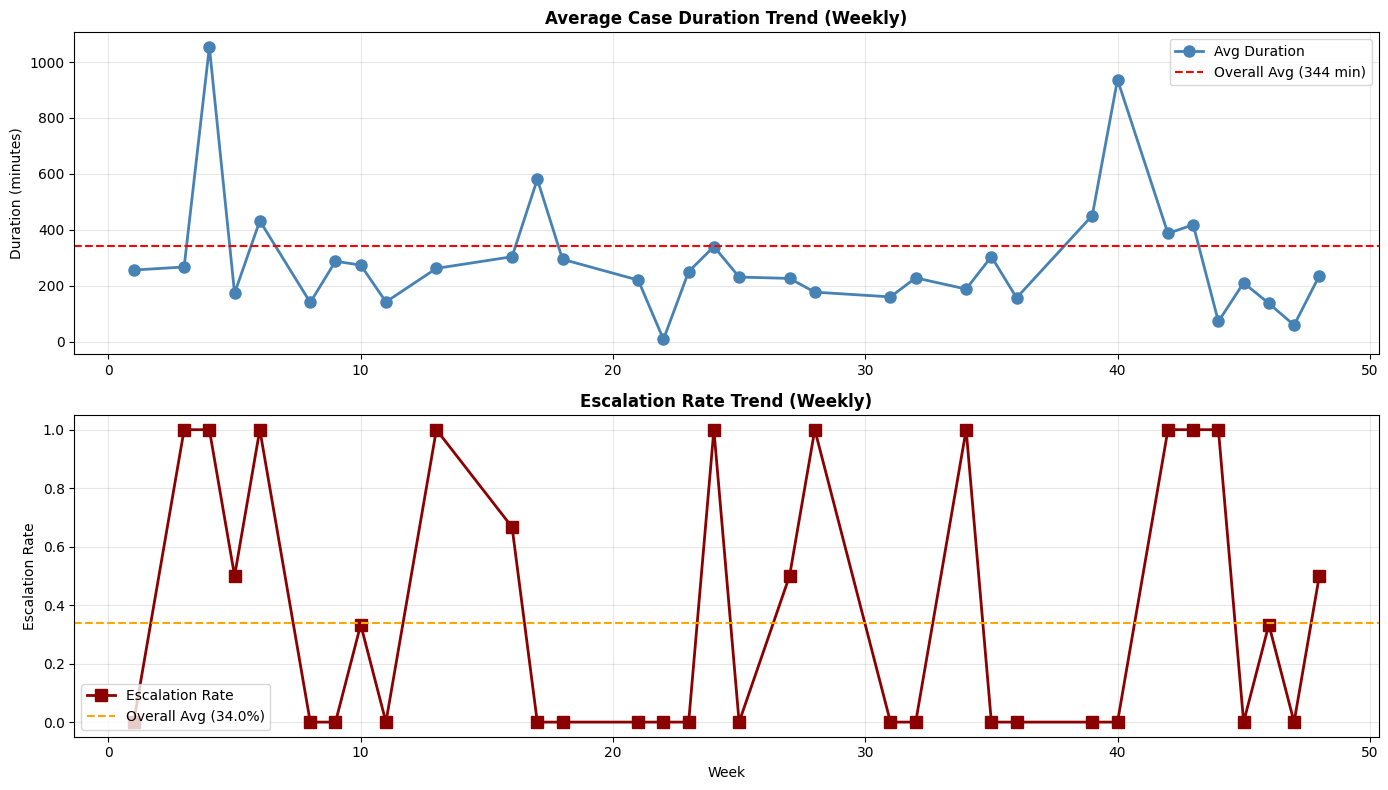

In [26]:
# Plot weekly trends
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Average duration trend
ax1.plot(weekly_df['week'], weekly_df['avg_duration'], marker='o', linewidth=2, 
         markersize=8, color='steelblue', label='Avg Duration')
ax1.axhline(y=baseline_metrics['avg_duration'], color='red', linestyle='--', 
            label=f'Overall Avg ({baseline_metrics["avg_duration"]:.0f} min)')
ax1.set_title('Average Case Duration Trend (Weekly)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Duration (minutes)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Escalation rate trend
ax2.plot(weekly_df['week'], weekly_df['escalation_rate'], marker='s', linewidth=2, 
         markersize=8, color='darkred', label='Escalation Rate')
ax2.axhline(y=baseline_metrics['escalation_rate'], color='orange', linestyle='--', 
            label=f'Overall Avg ({baseline_metrics["escalation_rate"]:.1%})')
ax2.set_title('Escalation Rate Trend (Weekly)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Week')
ax2.set_ylabel('Escalation Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Exercises

### Exercise 1: Build a Directly-Follows Graph

**Task**: Implement `build_directly_follows_graph()` to construct a DFG from events.

**Expected output**: NetworkX DiGraph with:
- Nodes: All unique activities
- Edges: Weighted by transition frequency
- Can answer: "What's the most common transition?"

**Test**: Verify top transition is most common in DFG

In [27]:
# Exercise 1: Implement build_directly_follows_graph
# (Solution provided above - already implemented as build_dfg)

# Test it
test_dfg, test_edges = build_dfg(events_df)

# Get top transition
top_transition = max(test_edges.items(), key=lambda x: x[1])
print(f"\n✓ Exercise 1: Build DFG")
print(f"Top transition: {top_transition[0][0]} → {top_transition[0][1]} (frequency: {top_transition[1]})")
print(f"Graph has {test_dfg.number_of_nodes()} nodes and {test_dfg.number_of_edges()} edges")


✓ Exercise 1: Build DFG
Top transition: Ticket Created → Assigned to Agent (frequency: 50)
Graph has 7 nodes and 11 edges


### Exercise 2: Find Process Variants

**Task**: Implement `find_process_variants()` to extract unique activity sequences.

**Expected output**: DataFrame with:
- Variant sequences
- Frequency of each variant
- Average duration per variant

**Test**: Top variant should be > 40% of all cases

In [28]:
# Exercise 2: Find variants
# (Solution provided above - already implemented as find_process_variants)

test_variants = find_process_variants(events_df)

print(f"\n✓ Exercise 2: Find Process Variants")
print(f"Top variant frequency: {test_variants['frequency'].iloc[0]} cases")
print(f"Coverage: {test_variants['frequency'].iloc[0] / events_df['case_id'].nunique() * 100:.1f}% of all cases")
print(f"Total unique variants: {len(test_variants)}")


✓ Exercise 2: Find Process Variants
Top variant frequency: 28 cases
Coverage: 56.0% of all cases
Total unique variants: 7


### Exercise 3: Detect Anomalies

**Task**: Implement `detect_anomalies()` to find unusual cases (rework, long duration, many handoffs).

**Expected output**: DataFrame with:
- Case IDs with anomalies
- Type of anomaly
- Severity metrics

**Test**: Should find 5-20 stuck/reworked cases

In [29]:
# Exercise 3: Detect anomalies
def detect_anomalies(events_df, case_col='case_id', activity_col='activity', timestamp_col='timestamp'):
    """
    Detect unusual cases: rework loops, long duration, many handoffs.
    
    Returns:
        DataFrame with anomalies and severity
    """
    anomalies = []
    
    # Add rework cases
    rework_cases = detect_rework_loops(events_df)
    for _, row in rework_cases.iterrows():
        anomalies.append({
            'case_id': row['case_id'],
            'anomaly_type': 'Rework',
            'severity': row['rework_count']
        })
    
    # Add stuck cases
    stuck = detect_stuck_cases(events_df)
    for _, row in stuck.iterrows():
        anomalies.append({
            'case_id': row['case_id'],
            'anomaly_type': row['reason'],
            'severity': row['duration_minutes']
        })
    
    return pd.DataFrame(anomalies).drop_duplicates()

test_anomalies = detect_anomalies(events_df)

print(f"\n✓ Exercise 3: Detect Anomalies")
print(f"Total anomalies found: {len(test_anomalies)}")
print(f"By type: {test_anomalies['anomaly_type'].value_counts().to_dict()}")


✓ Exercise 3: Detect Anomalies
Total anomalies found: 18
By type: {'Rework': 10, 'Long duration': 6, 'Multiple handoffs': 2}


## 9. Advanced Analysis

In [30]:
# Resource (agent) performance analysis
actor_metrics = []

for actor in events_df['actor'].unique():
    actor_events = events_df[events_df['actor'] == actor]
    cases_handled = actor_events['case_id'].nunique()
    
    if cases_handled > 0:
        avg_resolution_time = actor_events.groupby('case_id')['duration_minutes'].sum().mean()
        escalation_count = len(actor_events[actor_events['activity'] == 'Escalated'])
        escalation_rate = escalation_count / cases_handled if cases_handled > 0 else 0
        
        actor_metrics.append({
            'actor': actor,
            'cases_handled': cases_handled,
            'avg_resolution_time': avg_resolution_time,
            'escalation_count': escalation_count,
            'escalation_rate': escalation_rate
        })

actor_df = pd.DataFrame(actor_metrics).sort_values('cases_handled', ascending=False)

print(f"\n=== Agent Performance Analysis ===")
print(actor_df.head(10).to_string(index=False))


=== Agent Performance Analysis ===
      actor  cases_handled  avg_resolution_time  escalation_count  escalation_rate
     SYSTEM             50             3.760000                 0         0.000000
AGENT_L1_01             21           284.238095                 0         0.000000
AGENT_L1_02             15           290.333333                 0         0.000000
AGENT_L1_03             14           112.642857                 0         0.000000
SR_AGENT_02              6           371.833333                 6         1.000000
SR_AGENT_01              6           612.500000                 4         0.666667
AGENT_L2_01              5           215.200000                 5         1.000000
AGENT_L2_02              3           237.333333                 3         1.000000


In [31]:
# Summary comparison table
comparison_data = {
    'Metric': [
        'Avg Duration (min)',
        'Median Duration (min)',
        'p90 Duration (min)',
        'Escalation Rate',
        'Rework Rate'
    ],
    'Baseline': [
        f"{baseline_metrics['avg_duration']:.1f}",
        f"{baseline_metrics['median_duration']:.1f}",
        f"{baseline_metrics['p90_duration']:.1f}",
        f"{baseline_metrics['escalation_rate']:.1%}",
        f"{baseline_metrics['rework_rate']:.1%}"
    ],
    'Scenario 1: Reduce Rework': [
        f"{scenario1_metrics['avg_duration']:.1f}",
        f"{scenario1_metrics['median_duration']:.1f}",
        f"{scenario1_metrics['p90_duration']:.1f}",
        f"{scenario1_metrics['escalation_rate']:.1%}",
        f"{scenario1_metrics['rework_rate']:.1%}"
    ],
    'Scenario 2: AI Intake': [
        f"{scenario2_metrics['avg_duration']:.1f}",
        f"{scenario2_metrics['median_duration']:.1f}",
        f"{scenario2_metrics['p90_duration']:.1f}",
        f"{scenario2_metrics['escalation_rate']:.1%}",
        f"{scenario2_metrics['rework_rate']:.1%}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print(f"\n=== Process Improvement Scenarios Comparison ===")
print(comparison_df.to_string(index=False))


=== Process Improvement Scenarios Comparison ===
               Metric Baseline Scenario 1: Reduce Rework Scenario 2: AI Intake
   Avg Duration (min)    343.6                     342.2                 343.6
Median Duration (min)    259.0                     250.0                 259.0
   p90 Duration (min)    782.0                     782.0                 782.0
      Escalation Rate    34.0%                     34.0%                 24.0%
          Rework Rate    20.0%                      0.0%                 20.0%


## Key Insights & Takeaways

### Process vs Entity Relationship Graphs

| Aspect | Process Graphs (Temporal) | Entity Graphs (Atemporal) |
|--------|---------------------------|---------------------------|
| **Time** | Has timestamps | Timeless |
| **Edges** | Activity sequences | Relationships |
| **Analysis** | Bottlenecks, variants, rework | Centrality, communities, paths |
| **Questions** | "What takes longest?" "Who escalates most?" | "Who's most important?" "Which groups collaborate?" |
| **Algorithms** | Process mining, DFG, conformance | PageRank, betweenness, clustering |

### When to Use Process Mining

- ✅ You have event logs with timestamps
- ✅ You want to discover the actual process (not the documented one)
- ✅ You need to identify bottlenecks or anomalies
- ✅ You want to measure process variants
- ✅ You need before/after comparison for improvements

### Common Pitfalls

1. **Ignoring timestamps**: Without time, you can't find bottlenecks
2. **Assuming process is fixed**: Real processes have variants and anomalies
3. **Missing context**: Why did escalation spike? Was it customer volume or system issue?
4. **Aggregate too much**: Losing detail hides important patterns
5. **Not validating**: Always check if discovered process matches reality

## Preview: Lesson 09

**Next: Neo4j Property Graph Modeling**

In Lesson 09, we'll move from NetworkX (in-memory graphs) to **Neo4j** (persistent graph database). We'll learn:

- Property graphs: Nodes and edges with attributes
- Multi-relationship modeling: Different types of edges
- Graph schema design: Planning structure for complex domains
- Loading data from CSV into Neo4j
- Querying with Cypher: The graph query language

Process graphs will become **temporal property graphs** with timestamps, durations, and resources as node/edge properties.